# Análisis Predictivo — Superstore

Pipeline completo: **Data Wrangling → EDA → Modelado Predictivo**

- **Dataset:** `Sample - Superstore.csv` (9994 transacciones retail)
- **Objetivo:** Predecir `Profit` usando variables de la transacción
- **Stack:** pandas, numpy, matplotlib, seaborn, scipy, scikit-learn

Cada fase incluye: (1) explicación de qué hacemos y por qué, (2) código ejecutable, (3) interpretación de los resultados.

### 0. Importaciones

Cargamos todas las librerías necesarias al inicio para que el notebook sea autónomo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## Fase 1: Data Wrangling
Carga, limpieza, transformación e ingeniería de features.

### 1.1 Carga e inspección inicial

Cargamos el CSV original. Usamos `encoding='cp1252'` porque el archivo tiene caracteres especiales.
Mostramos info básica, shape, head, describe y buscamos valores nulos.

In [2]:
# Carga del dataset original
df = pd.read_csv('Sample - Superstore.csv', encoding='cp1252')
print(f'Shape: {df.shape}')
print('\n--- info() ---')
df.info()
print('\n--- Primeras filas ---')
display(df.head())
print('\n--- Estadísticas descriptivas ---')
display(df.describe())
print('\n--- Valores nulos por columna ---')
print(df.isnull().sum())
print('\n--- Sesgo (skewness) de Sales y Profit ---')
print(df[['Sales','Profit']].skew())

Shape: (9994, 21)

--- info() ---
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



--- Estadísticas descriptivas ---


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000



--- Valores nulos por columna ---
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

--- Sesgo (skewness) de Sales y Profit ---
Sales     12.972752
Profit     7.561432
dtype: float64


### 1.2 Parseo de fechas

Convertimos `Order Date` y `Ship Date` a datetime y calculamos `ShippingDuration` (días entre pedido y envío).

In [3]:
# Parseo de fechas
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

# Duración de envío en días
df['ShippingDuration'] = (df['Ship Date'] - df['Order Date']).dt.days
print(f'ShippingDuration - min: {df["ShippingDuration"].min()}, max: {df["ShippingDuration"].max()}, media: {df["ShippingDuration"].mean():.1f}')
display(df[['Order Date','Ship Date','ShippingDuration']].head())

ShippingDuration - min: 0, max: 7, media: 4.0


,Order Date,Ship Date,ShippingDuration
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


### 1.3 Manejo de valores nulos

Identificamos columnas con nulos. Los nulos en columnas numéricas como `Sales` o `Profit` **no se eliminan** — se investigan.

In [4]:
# Reporte de nulos
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
if len(nulls) > 0:
    print('Columnas con valores nulos:')
    print(nulls)
    # Postal Code suele ser la única con nulos en este dataset
    if 'Postal Code' in nulls.index:
        df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)
        print('\n→ Postal Code imputado con 0')
else:
    print('No hay valores nulos en el dataset.')

No hay valores nulos en el dataset.


### 1.4 Detección de outliers

Usamos el método IQR (rango intercuartílico) para detectar valores extremos en `Sales` y `Profit`.
**No los eliminamos** — creamos una columna `IsOutlier` para que el modelo (o el analista) decida cómo tratarlos.

In [5]:
# Detección de outliers con IQR
def flag_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

outliers_sales = flag_outliers_iqr(df['Sales'])
outliers_profit = flag_outliers_iqr(df['Profit'])
df['IsOutlier'] = (outliers_sales | outliers_profit).astype(int)

print(f'Filas totales: {len(df)}')
print(f'Outliers en Sales: {outliers_sales.sum()}')
print(f'Outliers en Profit: {outliers_profit.sum()}')
print(f'Filas marcadas como outlier (Sales o Profit): {df["IsOutlier"].sum()} ({df["IsOutlier"].mean()*100:.1f}%)')

Filas totales: 9994
Outliers en Sales: 1167
Outliers en Profit: 1881
Filas marcadas como outlier (Sales o Profit): 2120 (21.2%)


### 1.5 Ingeniería de features

Creamos nuevas columnas que pueden ayudar al modelo a capturar patrones:
- **Temporales:** OrderYear, OrderMonth, OrderDayOfWeek, IsWeekend
- **Negocio:** ProfitMargin, SalesPerDay, Category_Segment
- **Discretización:** DiscountLevel (None/Low/Medium/High)
- **Transformación:** LogSales / LogProfit si el skew es > 1.0

In [6]:
# Features temporales
df['OrderYear'] = df['Order Date'].dt.year
df['OrderMonth'] = df['Order Date'].dt.month
df['OrderDayOfWeek'] = df['Order Date'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['IsWeekend'] = (df['OrderDayOfWeek'] >= 5).astype(int)

# Features de negocio
df['ProfitMargin'] = (df['Profit'] / df['Sales']).replace([np.inf, -np.inf], np.nan).fillna(0)
df['SalesPerDay'] = df['Sales'] / (df['ShippingDuration'] + 1)
df['Category_Segment'] = df['Category'] + '_' + df['Segment']

# Discretización de descuento
bins = [-0.01, 0, 0.2, 0.5, 1.0]
labels = ['None', 'Low', 'Medium', 'High']
df['DiscountLevel'] = pd.cut(df['Discount'], bins=bins, labels=labels)

# Transformación logarítmica si hay alto sesgo
for col in ['Sales', 'Profit']:
    if df[col].skew() > 1.0:
        df[f'Log{col}'] = np.log1p(df[col] - df[col].min() + 1)  # log1p con shift para negativos
        print(f'Log{col} creado (sesgo original: {df[col].skew():.2f})')

print('\nNuevas columnas:')
new_cols = ['OrderYear','OrderMonth','OrderDayOfWeek','IsWeekend','ProfitMargin','SalesPerDay','Category_Segment','DiscountLevel']
print(new_cols)
if 'LogSales' in df.columns:
    print(['LogSales', 'LogProfit'])

LogSales creado (sesgo original: 12.97)
LogProfit creado (sesgo original: 7.56)

Nuevas columnas:
['OrderYear', 'OrderMonth', 'OrderDayOfWeek', 'IsWeekend', 'ProfitMargin', 'SalesPerDay', 'Category_Segment', 'DiscountLevel']
['LogSales', 'LogProfit']


### 1.6 Codificación de variables categóricas

Convertimos categorías a variables numéricas con **one-hot encoding**.
Usamos `drop_first=True` para evitar multicolinealidad (una columna redundante que no aporta información).

In [7]:
# One-hot encoding con drop_first=True
cat_cols = ['Category', 'Sub-Category', 'Segment', 'Ship Mode', 'Region']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
print(f'Shape después de encoding: {df.shape}')
print(f'Columnas categóricas codificadas: {cat_cols}')

Shape después de encoding: (9994, 54)
Columnas categóricas codificadas: ['Category', 'Sub-Category', 'Segment', 'Ship Mode', 'Region']


### 1.7 Eliminación de columnas de bajo valor

Eliminamos columnas de alta cardinalidad (IDs únicos por fila) o redundantes que no aportan señal predictiva.

In [8]:
# Columnas a eliminar
cols_to_drop = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 
                'Product ID', 'Product Name', 'Country', 'Postal Code']
# Solo eliminamos las que existen en el dataframe
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f'Columnas eliminadas: {cols_to_drop}')
print(f'Shape final: {df.shape}')

Columnas eliminadas: ['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Product ID', 'Product Name', 'Country', 'Postal Code']
Shape final: (9994, 46)


### 1.8 Verificación final y exportación

Confirmamos que no queden nulos, revisamos tipos de datos, mostramos uso de memoria y guardamos el CSV limpio.

In [10]:
# Verificación final
nulls_final = df.isnull().sum()
nulls_final = nulls_final[nulls_final > 0]
if len(nulls_final) > 0:
    print('⚠️ Aún hay nulos:')
    print(nulls_final)
else:
    print('✅ No hay valores nulos en el dataset limpio.')

print(f'\nShape final: {df.shape}')
print('\n--- Primeras filas del dataset limpio ---')
display(df.head())

# Uso de memoria
mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f'\nMemoria usada: {mem_mb:.2f} MB')

# Exportar
df.to_csv('superstore_clean.csv', index=False)
print('\nDataset limpio guardado en: superstore_clean.csv')

✅ No hay valores nulos en el dataset limpio.

Shape final: (9994, 46)

--- Primeras filas del dataset limpio ---


,Order Date,Ship Date,City,State,Sales,Quantity,Discount,Profit,ShippingDuration,IsOutlier,...,Sub-Category_Supplies,Sub-Category_Tables,Segment_Corporate,Segment_Home Office,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Region_East,Region_South,Region_West
0,2016-11-08,2016-11-11,Henderson,Kentucky,261.9600,2,0.00,41.9136,3,0,...,0,0,0,0,0,1,0,0,1,0
1,2016-11-08,2016-11-11,Henderson,Kentucky,731.9400,3,0.00,219.5820,3,1,...,0,0,0,0,0,1,0,0,1,0
2,2016-06-12,2016-06-16,Los Angeles,California,14.6200,2,0.00,6.8714,4,0,...,0,0,1,0,0,1,0,0,0,1
3,2015-10-11,2015-10-18,Fort Lauderdale,Florida,957.5775,5,0.45,-383.0310,7,1,...,0,1,0,0,0,0,1,0,1,0
4,2015-10-11,2015-10-18,Fort Lauderdale,Florida,22.3680,2,0.20,2.5164,7,0,...,0,0,0,0,0,0,1,0,1,0



Memoria usada: 4.88 MB

Dataset limpio guardado en: superstore_clean.csv


**Resumen Fase 1:**
- Se cargaron 9994 transacciones con 21 columnas originales.
- Se parsearon fechas y se calculó duración de envío.
- Se detectaron outliers sin eliminarlos (columna `IsOutlier`).
- Se crearon features temporales, de negocio y discretizaciones.
- Se codificaron categorías con one-hot encoding.
- Se exportó `superstore_clean.csv` con todas las transformaciones.

---
## Fase 2: Análisis Exploratorio de Datos (EDA)
Exploramos el dataset limpio para encontrar patrones, correlaciones e insights.

### 2.1 Carga de datos limpios

Partimos desde el CSV limpio generado en la fase anterior.

In [11]:
# Carga del dataset limpio
eda_df = pd.read_csv('superstore_clean.csv')
print(f'Shape: {eda_df.shape}')
eda_df.info()
display(eda_df.describe())

Shape: (9994, 46)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order Date                9994 non-null   str    
 1   Ship Date                 9994 non-null   str    
 2   City                      9994 non-null   str    
 3   State                     9994 non-null   str    
 4   Sales                     9994 non-null   float64
 5   Quantity                  9994 non-null   int64  
 6   Discount                  9994 non-null   float64
 7   Profit                    9994 non-null   float64
 8   ShippingDuration          9994 non-null   int64  
 9   IsOutlier                 9994 non-null   int64  
 10  OrderYear                 9994 non-null   int64  
 11  OrderMonth                9994 non-null   int64  
 12  OrderDayOfWeek            9994 non-null   int64  
 13  IsWeekend                 9994 non-null   int64  
 14  P

,Sales,Quantity,Discount,Profit,ShippingDuration,IsOutlier,OrderYear,OrderMonth,OrderDayOfWeek,IsWeekend,...,Sub-Category_Supplies,Sub-Category_Tables,Segment_Corporate,Segment_Home Office,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Region_East,Region_South,Region_West
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,...,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896,3.958175,0.212127,2015.722233,7.809686,3.206324,0.336702,...,0.019011,0.031919,0.302181,0.178407,0.054333,0.194617,0.597158,0.284971,0.162097,0.320492
std,623.245101,2.225110,0.206452,234.260108,1.747567,0.408835,1.123555,3.284654,2.122925,0.472606,...,0.136572,0.175794,0.459226,0.382874,0.226684,0.395925,0.490494,0.451423,0.368558,0.466689
min,0.444000,1.000000,0.000000,-6599.978000,0.000000,0.000000,2014.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.280000,2.000000,0.000000,1.728750,3.000000,0.000000,2015.000000,5.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.490000,3.000000,0.200000,8.666500,4.000000,0.000000,2016.000000,9.000000,4.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,209.940000,5.000000,0.200000,29.364000,5.000000,0.000000,2017.000000,11.000000,5.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
max,22638.480000,14.000000,0.800000,8399.976000,7.000000,1.000000,2017.000000,12.000000,6.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 2.2 Análisis univariado

Visualizamos la distribución de las variables más importantes: Sales, Profit, Discount.
Comparamos las originales con sus versiones logarítmicas si existen.

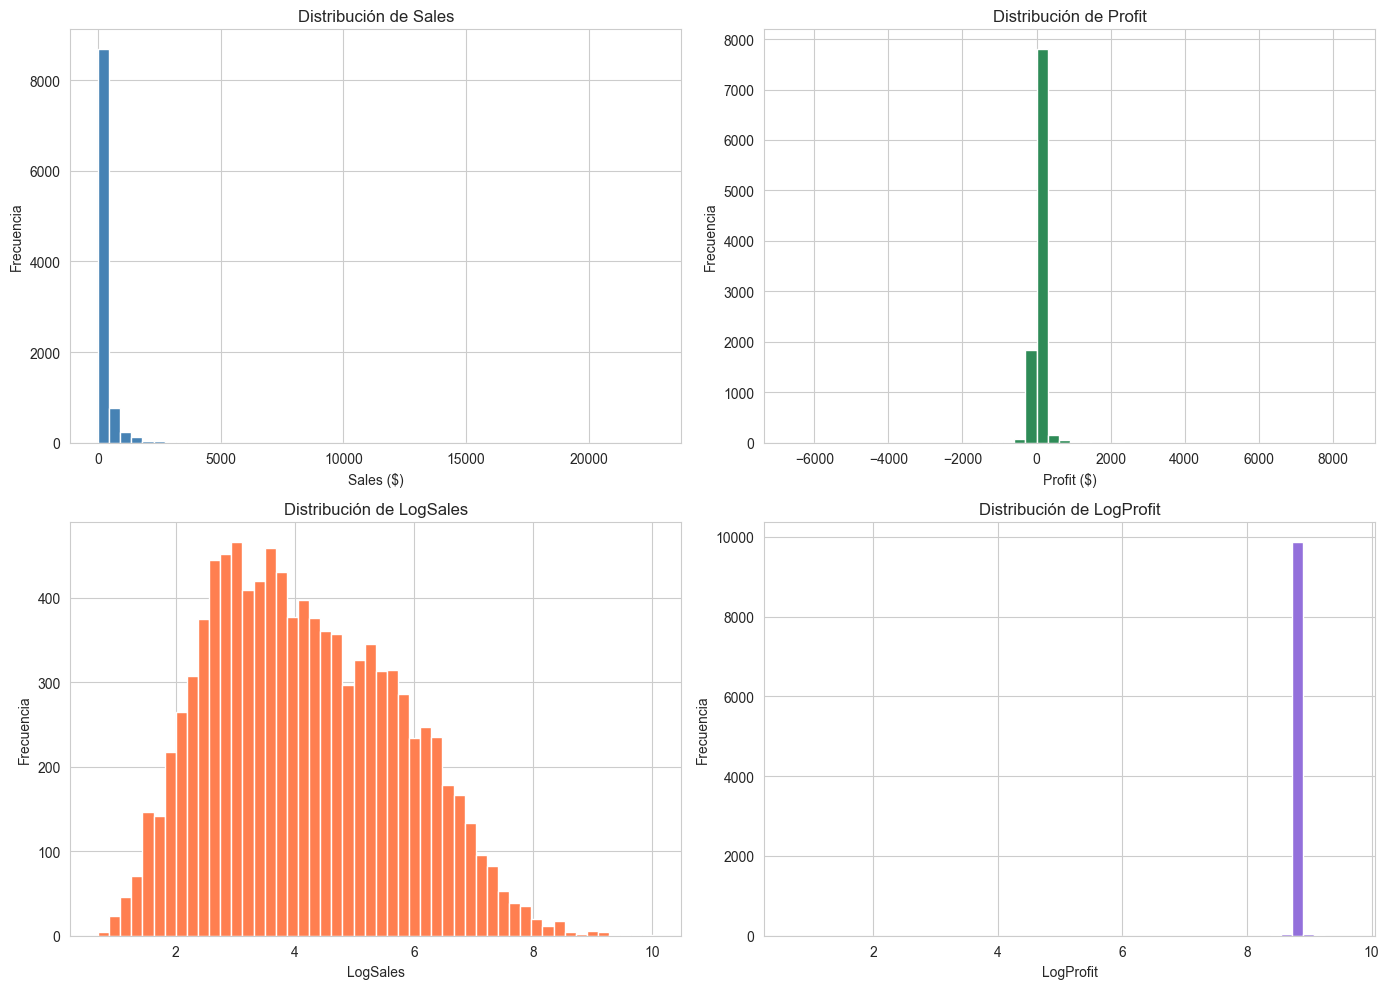

Nota: Ambas variables muestran alta asimetría positiva (cola larga a la derecha).


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sales
axes[0,0].hist(eda_df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribución de Sales')
axes[0,0].set_xlabel('Sales ($)')
axes[0,0].set_ylabel('Frecuencia')

# Profit
axes[0,1].hist(eda_df['Profit'], bins=50, color='seagreen', edgecolor='white')
axes[0,1].set_title('Distribución de Profit')
axes[0,1].set_xlabel('Profit ($)')
axes[0,1].set_ylabel('Frecuencia')

# LogSales si existe
if 'LogSales' in eda_df.columns:
    axes[1,0].hist(eda_df['LogSales'], bins=50, color='coral', edgecolor='white')
    axes[1,0].set_title('Distribución de LogSales')
    axes[1,0].set_xlabel('LogSales')
    axes[1,0].set_ylabel('Frecuencia')
else:
    axes[1,0].axis('off')

# LogProfit si existe
if 'LogProfit' in eda_df.columns:
    axes[1,1].hist(eda_df['LogProfit'], bins=50, color='mediumpurple', edgecolor='white')
    axes[1,1].set_title('Distribución de LogProfit')
    axes[1,1].set_xlabel('LogProfit')
    axes[1,1].set_ylabel('Frecuencia')
else:
    axes[1,1].axis('off')

plt.tight_layout()
plt.show()

print('Nota: Ambas variables muestran alta asimetría positiva (cola larga a la derecha).')

C:\Users\Brandon\AppData\Local\Temp\ipykernel_20164\1274088758.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=eda_df, x='Category_Recon', y='Profit', palette='Set2')


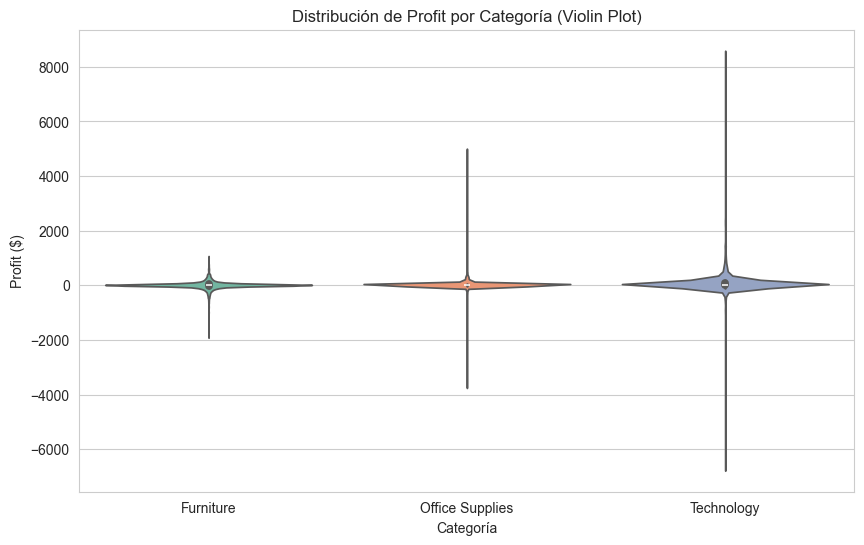

In [13]:
# Violin plot de Profit por Category
# Necesitamos reconstruir Category desde las columnas dummy
category_cols = [c for c in eda_df.columns if c.startswith('Category_')]
if len(category_cols) > 0:
    eda_df['Category_Recon'] = ''
    for c in category_cols:
        cat_name = c.replace('Category_', '')
        eda_df.loc[eda_df[c] == 1, 'Category_Recon'] = cat_name
    # La categoría base (la que fue droppeada) es la primera en orden alfabético
    base_cat = sorted(['Furniture','Office Supplies','Technology'])[0]
    eda_df.loc[eda_df['Category_Recon'] == '', 'Category_Recon'] = base_cat
    
    plt.figure(figsize=(10,6))
    sns.violinplot(data=eda_df, x='Category_Recon', y='Profit', palette='Set2')
    plt.title('Distribución de Profit por Categoría (Violin Plot)')
    plt.xlabel('Categoría')
    plt.ylabel('Profit ($)')
    plt.show()
else:
    print('No se encontraron columnas Category_ para reconstruir.')

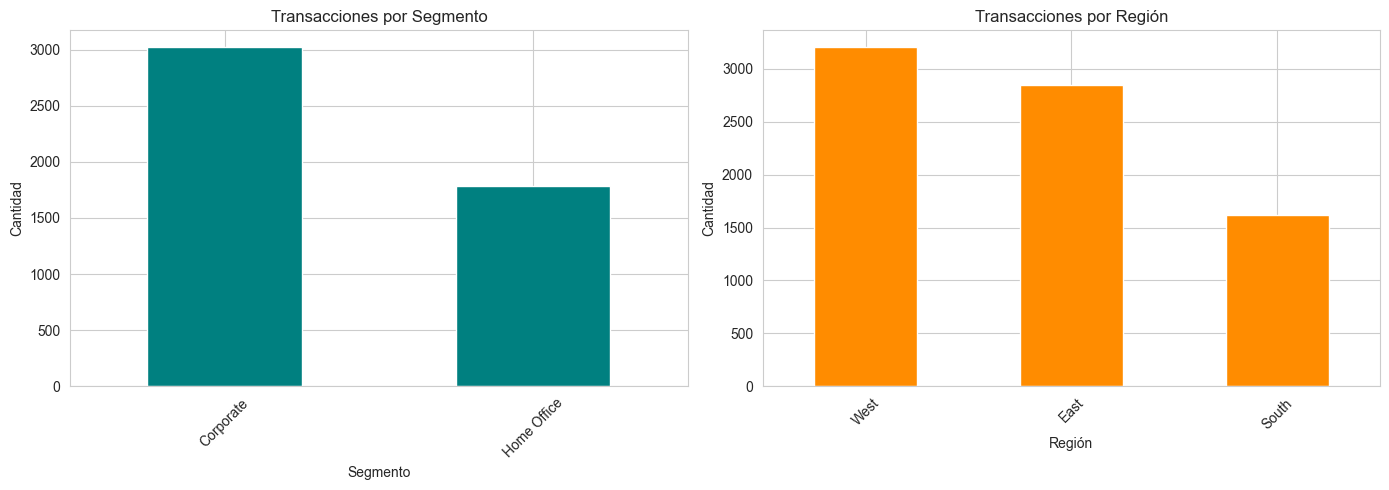

In [14]:
# Gráficos de barras: conteo por Segment, Region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment
segment_cols = [c for c in eda_df.columns if c.startswith('Segment_')]
if segment_cols:
    seg_counts = eda_df[segment_cols].sum().sort_values(ascending=False)
    seg_counts.index = [s.replace('Segment_', '') for s in seg_counts.index]
    seg_counts.plot(kind='bar', ax=axes[0], color='teal')
    axes[0].set_title('Transacciones por Segmento')
    axes[0].set_xlabel('Segmento')
    axes[0].set_ylabel('Cantidad')
    axes[0].tick_params(axis='x', rotation=45)

# Region
region_cols = [c for c in eda_df.columns if c.startswith('Region_')]
if region_cols:
    reg_counts = eda_df[region_cols].sum().sort_values(ascending=False)
    reg_counts.index = [r.replace('Region_', '') for r in reg_counts.index]
    reg_counts.plot(kind='bar', ax=axes[1], color='darkorange')
    axes[1].set_title('Transacciones por Región')
    axes[1].set_xlabel('Región')
    axes[1].set_ylabel('Cantidad')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.3 Análisis bivariado

Exploramos relaciones entre variables. Usamos correlación de **Spearman** porque captura relaciones no lineales.

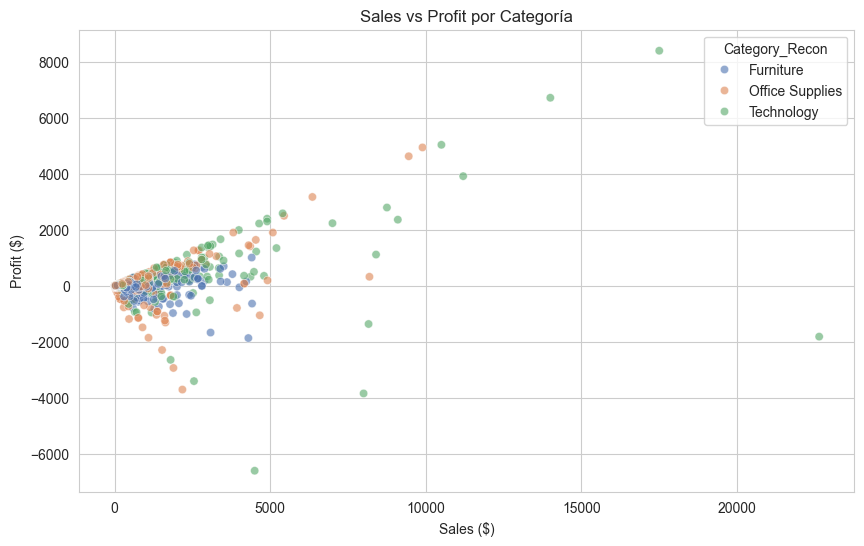

Observación: Hay una relación positiva general, pero con mucha dispersión.
Algunos puntos con altas ventas tienen profit negativo (descuentos agresivos).


In [15]:
# Scatter: Sales vs Profit coloreado por Category
plt.figure(figsize=(10, 6))
if 'Category_Recon' in eda_df.columns:
    sns.scatterplot(data=eda_df, x='Sales', y='Profit', hue='Category_Recon', alpha=0.6, palette='deep')
    plt.title('Sales vs Profit por Categoría')
else:
    sns.scatterplot(data=eda_df, x='Sales', y='Profit', alpha=0.6, color='steelblue')
    plt.title('Sales vs Profit')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.show()

print('Observación: Hay una relación positiva general, pero con mucha dispersión.')
print('Algunos puntos con altas ventas tienen profit negativo (descuentos agresivos).')

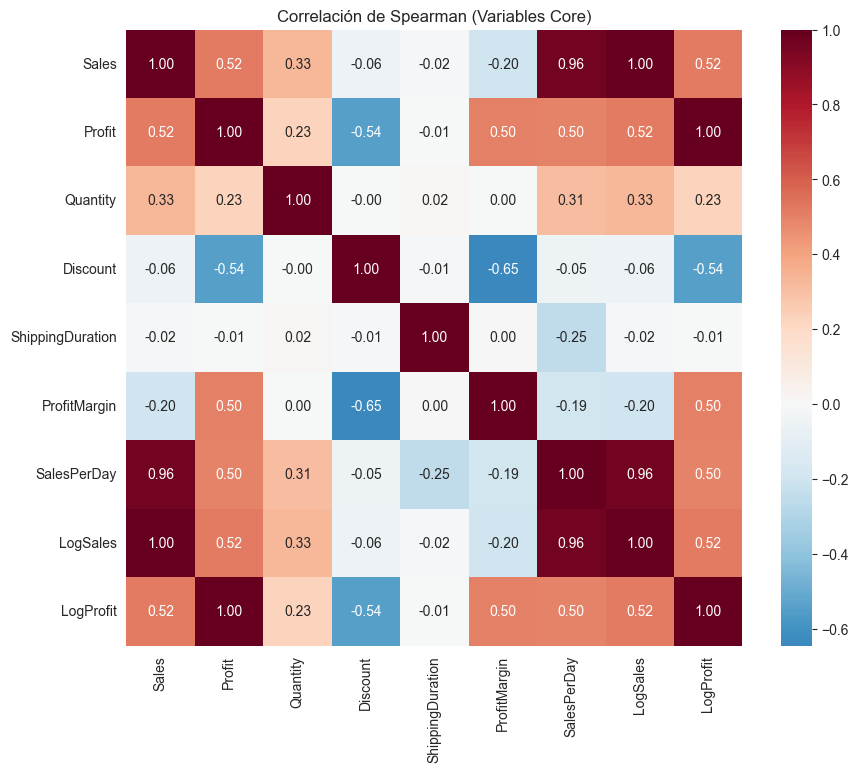

In [16]:
# Correlación de Spearman
numeric_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()
# Excluir columnas dummy para no sobrecargar el heatmap
core_cols = ['Sales','Profit','Quantity','Discount','ShippingDuration','ProfitMargin','SalesPerDay']
if 'LogSales' in eda_df.columns:
    core_cols += ['LogSales','LogProfit']
core_cols = [c for c in core_cols if c in numeric_cols]

corr = eda_df[core_cols].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('Correlación de Spearman (Variables Core)')
plt.show()

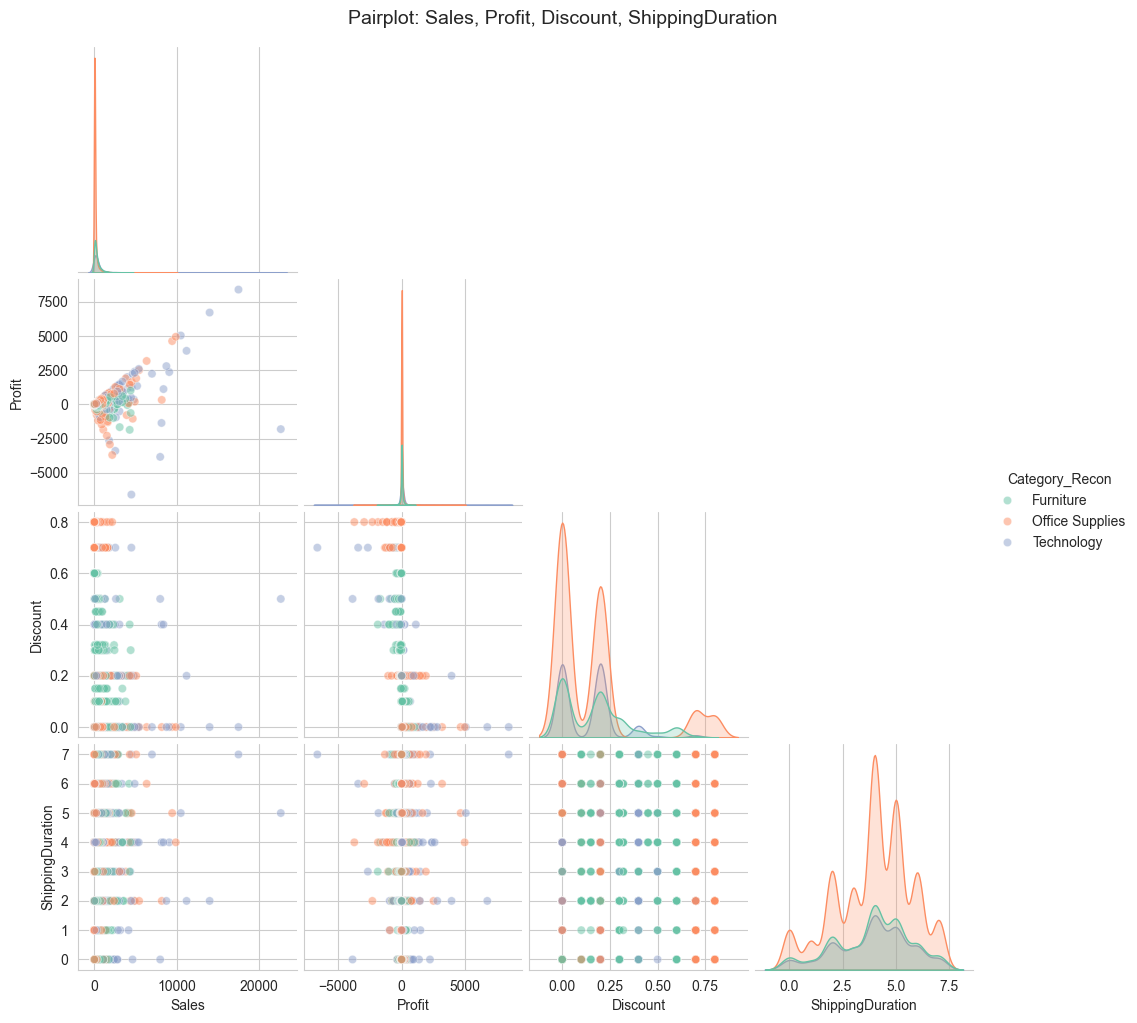

In [17]:
# Pairplot de variables clave
pair_cols = ['Sales','Profit','Discount','ShippingDuration']
if 'Category_Recon' in eda_df.columns and len(pair_cols) <= 4:
    sns.pairplot(eda_df[pair_cols + ['Category_Recon']], hue='Category_Recon',
                 diag_kind='kde', palette='Set2', corner=True, plot_kws={'alpha':0.5})
    plt.suptitle('Pairplot: Sales, Profit, Discount, ShippingDuration', y=1.02, size=14)
    plt.show()
else:
    sns.pairplot(eda_df[pair_cols], diag_kind='kde', corner=True)
    plt.suptitle('Pairplot: Sales, Profit, Discount, ShippingDuration', y=1.02, size=14)
    plt.show()

### 2.4 Análisis de segmentos

Cruzamos Categoría × Segmento para ver qué combinaciones son más rentables.

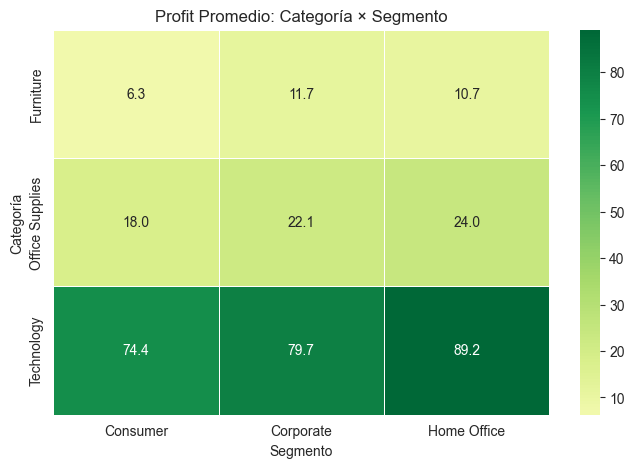

In [18]:
# Reconstruir Category y Segment desde dummies
segment_cols = [c for c in eda_df.columns if c.startswith('Segment_')]
if len(segment_cols) > 0 and 'Category_Recon' in eda_df.columns:
    eda_df['Segment_Recon'] = ''
    for c in segment_cols:
        seg_name = c.replace('Segment_', '')
        eda_df.loc[eda_df[c] == 1, 'Segment_Recon'] = seg_name
    base_seg = sorted(['Consumer','Corporate','Home Office'])[0]
    eda_df.loc[eda_df['Segment_Recon'] == '', 'Segment_Recon'] = base_seg
    
    # Pivot table
    pivot = eda_df.groupby(['Category_Recon','Segment_Recon'])['Profit'].mean().unstack()
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0, linewidths=0.5)
    plt.title('Profit Promedio: Categoría × Segmento')
    plt.ylabel('Categoría')
    plt.xlabel('Segmento')
    plt.show()
else:
    print('No se pueden reconstruir Category y Segment.')

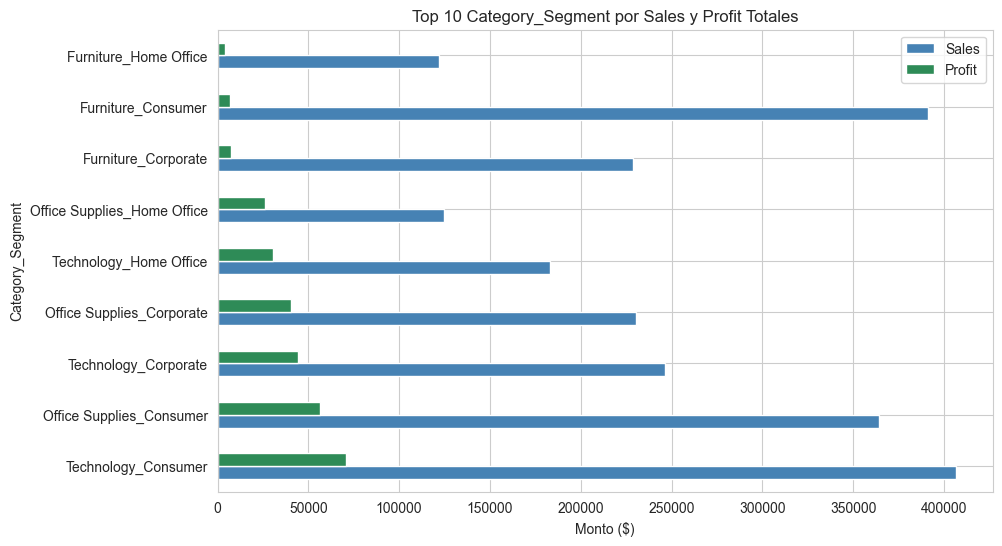

In [19]:
# Top 10 Category_Segment por Profit total
if 'Category_Segment' in eda_df.columns:
    top_segments = eda_df.groupby('Category_Segment').agg({'Sales':'sum','Profit':'sum'}).sort_values('Profit', ascending=False).head(10)
    top_segments.plot(kind='barh', figsize=(10, 6), color=['steelblue','seagreen'])
    plt.title('Top 10 Category_Segment por Sales y Profit Totales')
    plt.xlabel('Monto ($)')
    plt.show()
else:
    print('Columna Category_Segment no encontrada.')

### 2.5 Análisis temporal

Analizamos tendencias de ventas y ganancias a lo largo del tiempo.

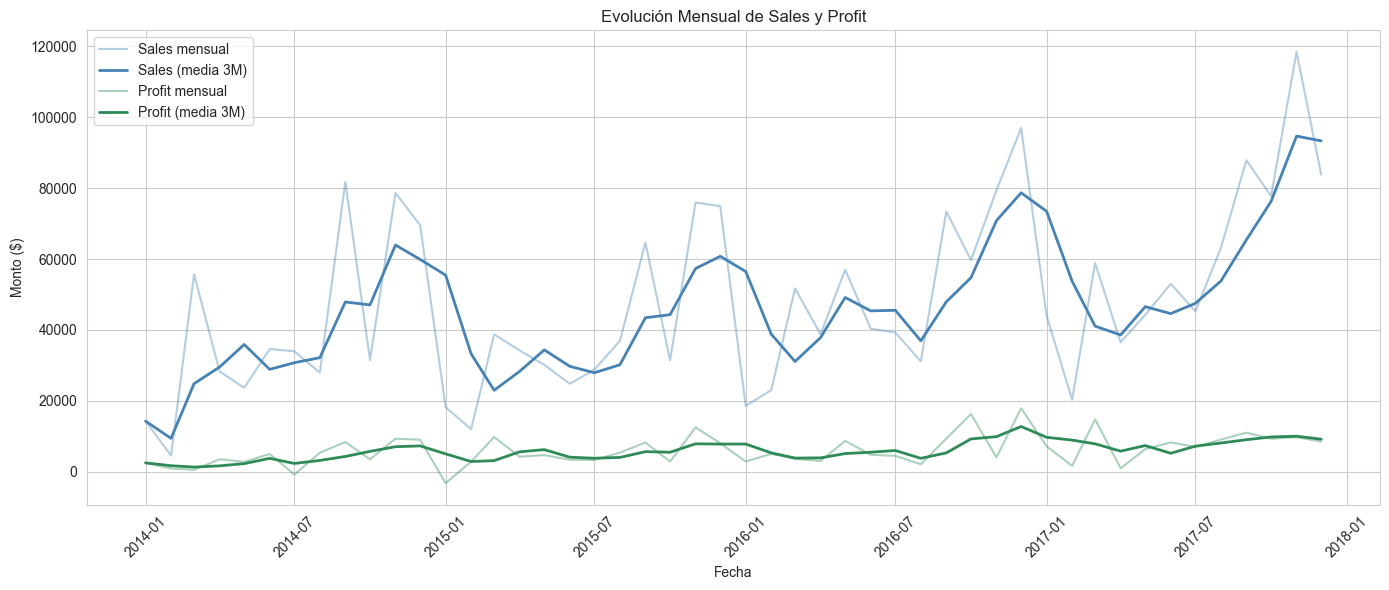

In [20]:
# Asegurarnos de tener las fechas originales (necesitamos recargar el CSV original para fechas)
raw = pd.read_csv('Sample - Superstore.csv', encoding='cp1252')
raw['Order Date'] = pd.to_datetime(raw['Order Date'], format='%m/%d/%Y')
raw['OrderYearMonth'] = raw['Order Date'].dt.to_period('M')

# Agregación mensual
monthly = raw.groupby('OrderYearMonth').agg({'Sales':'sum','Profit':'sum'}).reset_index()
monthly['OrderYearMonth'] = monthly['OrderYearMonth'].dt.to_timestamp()

# Rolling mean 3 meses
monthly['Sales_3M'] = monthly['Sales'].rolling(window=3, min_periods=1).mean()
monthly['Profit_3M'] = monthly['Profit'].rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly['OrderYearMonth'], monthly['Sales'], alpha=0.4, label='Sales mensual', color='steelblue')
plt.plot(monthly['OrderYearMonth'], monthly['Sales_3M'], label='Sales (media 3M)', color='steelblue', linewidth=2)
plt.plot(monthly['OrderYearMonth'], monthly['Profit'], alpha=0.4, label='Profit mensual', color='seagreen')
plt.plot(monthly['OrderYearMonth'], monthly['Profit_3M'], label='Profit (media 3M)', color='seagreen', linewidth=2)
plt.title('Evolución Mensual de Sales y Profit')
plt.xlabel('Fecha')
plt.ylabel('Monto ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

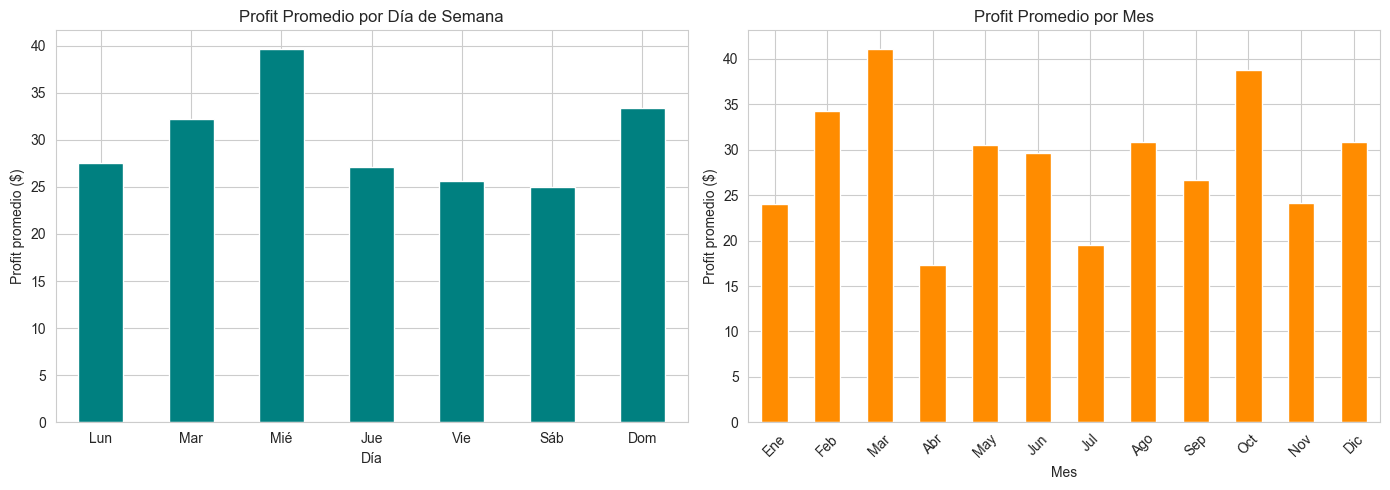

In [21]:
# Profit promedio por día de semana y por mes
raw['OrderDayOfWeek'] = raw['Order Date'].dt.dayofweek
raw['OrderMonth'] = raw['Order Date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por día de semana
dow_names = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
dow_profit = raw.groupby('OrderDayOfWeek')['Profit'].mean()
dow_profit.index = [dow_names[i] for i in dow_profit.index]
dow_profit.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Profit Promedio por Día de Semana')
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Profit promedio ($)')
axes[0].tick_params(axis='x', rotation=0)

# Por mes
month_names = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
month_profit = raw.groupby('OrderMonth')['Profit'].mean()
month_profit.index = [month_names[i-1] for i in month_profit.index]
month_profit.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Profit Promedio por Mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Profit promedio ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.6 Spotlight de outliers

Revisamos las transacciones más extremas para entender si son casos reales o errores de datos.

In [22]:
# Top / Bottom por Profit
print('=== TOP 5 TRANSACCIONES POR PROFIT ===')
display(raw.nlargest(5, 'Profit')[['Order Date','Category','Segment','Region','Sales','Quantity','Discount','Profit']])

print('\n=== BOTTOM 5 TRANSACCIONES POR PROFIT ===')
display(raw.nsmallest(5, 'Profit')[['Order Date','Category','Segment','Region','Sales','Quantity','Discount','Profit']])

print('\n=== TOP 5 TRANSACCIONES POR SALES ===')
display(raw.nlargest(5, 'Sales')[['Order Date','Category','Segment','Region','Sales','Quantity','Discount','Profit']])

=== TOP 5 TRANSACCIONES POR PROFIT ===


,Order Date,Category,Segment,Region,Sales,Quantity,Discount,Profit
6826,2016-10-02,Technology,Corporate,Central,17499.95,5,0.0,8399.9760
8153,2017-03-23,Technology,Consumer,West,13999.96,4,0.0,6719.9808
4190,2017-11-17,Technology,Consumer,East,10499.97,3,0.0,5039.9856
9039,2016-12-17,Office Supplies,Consumer,Central,9892.74,13,0.0,4946.3700
4098,2014-09-23,Office Supplies,Consumer,Central,9449.95,5,0.0,4630.4755



=== BOTTOM 5 TRANSACCIONES POR PROFIT ===


,Order Date,Category,Segment,Region,Sales,Quantity,Discount,Profit
7772,2016-11-25,Technology,Consumer,East,4499.985,5,0.7,-6599.9780
683,2017-11-04,Technology,Corporate,South,7999.980,4,0.5,-3839.9904
9774,2014-07-26,Office Supplies,Consumer,Central,2177.584,8,0.8,-3701.8928
3011,2017-04-17,Technology,Home Office,West,2549.985,5,0.7,-3399.9800
4991,2017-12-07,Office Supplies,Corporate,Central,1889.990,5,0.8,-2929.4845



=== TOP 5 TRANSACCIONES POR SALES ===


,Order Date,Category,Segment,Region,Sales,Quantity,Discount,Profit
2697,2014-03-18,Technology,Home Office,South,22638.480,6,0.5,-1811.0784
6826,2016-10-02,Technology,Corporate,Central,17499.950,5,0.0,8399.9760
8153,2017-03-23,Technology,Consumer,West,13999.960,4,0.0,6719.9808
2623,2017-10-22,Technology,Home Office,East,11199.968,4,0.2,3919.9888
4190,2017-11-17,Technology,Consumer,East,10499.970,3,0.0,5039.9856


### 2.7 Hallazgos Clave

Resumen de los insights más importantes descubiertos en el EDA.

In [23]:
# Calcular estadísticas para los insights
cat_profit = raw.groupby('Category')['Profit'].sum().sort_values(ascending=False)
reg_profit = raw.groupby('Region')['Profit'].sum().sort_values(ascending=False)
seg_profit = raw.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
disc_impact = raw.groupby('DiscountLevel' if 'DiscountLevel' in raw.columns else pd.cut(raw['Discount'], bins=[-0.01,0,0.2,0.5,1.0], labels=['None','Low','Medium','High']))['Profit'].mean()
monthly_totals = raw.groupby(raw['Order Date'].dt.month)['Profit'].sum()
best_month = monthly_totals.idxmax()
worst_month = monthly_totals.idxmin()
month_names = {1:'Enero',2:'Febrero',3:'Marzo',4:'Abril',5:'Mayo',6:'Junio',7:'Julio',8:'Agosto',9:'Septiembre',10:'Octubre',11:'Noviembre',12:'Diciembre'}

print('=== INSIGHTS CUANTITATIVOS ===')
print(f"1. Categoría más rentable: {cat_profit.index[0]} (${cat_profit.iloc[0]:,.0f}) vs {cat_profit.index[-1]} (${cat_profit.iloc[-1]:,.0f})")
print(f"2. Región más rentable: {reg_profit.index[0]} (${reg_profit.iloc[0]:,.0f}) vs {reg_profit.index[-1]} (${reg_profit.iloc[-1]:,.0f})")
print(f"3. Segmento más rentable: {seg_profit.index[0]} (${seg_profit.iloc[0]:,.0f})")
print(f"4. Impacto del descuento: Profit promedio por nivel:")
for level, profit in disc_impact.items():
    print(f"   - {level}: ${profit:,.2f}")
print(f"5. Mejor mes para profit: {month_names[best_month]} (${monthly_totals[best_month]:,.0f})")
print(f"6. Peor mes para profit: {month_names[worst_month]} (${monthly_totals[worst_month]:,.0f})")

=== INSIGHTS CUANTITATIVOS ===
1. Categoría más rentable: Technology ($145,455) vs Furniture ($18,451)
2. Región más rentable: West ($108,418) vs Central ($39,706)
3. Segmento más rentable: Consumer ($134,119)
4. Impacto del descuento: Profit promedio por nivel:
   - None: $66.90
   - Low: $26.50
   - Medium: $-109.53
   - High: $-89.44
5. Mejor mes para profit: Diciembre ($43,369)
6. Peor mes para profit: Enero ($9,134)


---
## Fase 3: Modelado Predictivo
Entrenamos y evaluamos modelos para predecir `Profit`.

### 3.1 Preparación de datos

Separamos features (X) del target (y = Profit). Excluimos columnas transformadas del target.

In [24]:
# Cargar datos limpios
model_df = pd.read_csv('superstore_clean.csv')

# Separar X e y
y = model_df['Profit']
X = model_df.drop(columns=['Profit'])

# Excluir columnas derivadas del target o no numéricas
drop_model_cols = ['LogProfit', 'ProfitMargin', 'Category_Segment']
drop_model_cols = [c for c in drop_model_cols if c in X.columns]
X = X.drop(columns=drop_model_cols)
print(f'Columnas excluidas del modelado: {drop_model_cols}')

# Mantener solo columnas numéricas
X = X.select_dtypes(include=[np.number])

print(f'Features: {X.shape[1]} | Filas: {X.shape[0]}')
print(f'Target: Profit (media={y.mean():.2f}, std={y.std():.2f})')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')

Columnas excluidas del modelado: ['LogProfit', 'ProfitMargin', 'Category_Segment']
Features: 37 | Filas: 9994
Target: Profit (media=28.66, std=234.26)
Train: 7995 filas | Test: 1999 filas


### 3.2 Entrenamiento de modelos

Entrenamos 3 modelos con diferentes fortalezas:
- **Linear Regression:** baseline simple e interpretable
- **Ridge:** regresión lineal con regularización (evita overfitting)
- **Random Forest:** maneja relaciones no lineales

**Nota sobre métricas:** Profit tiene outliers extremos (-$6,600 a +$8,400). R² usa MSE que es muy sensible a outliers. MAE es más robusto. MAPE se infla con valores cercanos a cero.

In [26]:
# Entrenar modelos
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    results.append({'Modelo': name, 'R²': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape})
    print(f'{name}: R²={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.4f}')

results_df = pd.DataFrame(results)
print('\n=== Tabla Comparativa ===')

try:
    display(results_df.style.format({'R²':'{:.4f}','RMSE':'${:,.2f}','MAE':'${:,.2f}','MAPE':'{:.2%}'}))
except AttributeError:
    results_display = results_df.copy()
    results_display['R²'] = results_display['R²'].map(lambda x: f'{x:.4f}')
    results_display['RMSE'] = results_display['RMSE'].map(lambda x: f'${x:,.2f}')
    results_display['MAE'] = results_display['MAE'].map(lambda x: f'${x:,.2f}')
    results_display['MAPE'] = results_display['MAPE'].map(lambda x: f'{x:.2%}')
    display(results_display)

Linear Regression: R²=-0.8371, RMSE=298.45, MAE=72.55, MAPE=2933999275682572.0000
Ridge: R²=-0.8392, RMSE=298.62, MAE=72.44, MAPE=2936471165483463.5000
Random Forest: R²=-0.0062, RMSE=220.88, MAE=25.79, MAPE=2084531345068075.5000

=== Tabla Comparativa ===


,Modelo,R²,RMSE,MAE,MAPE
0,Linear Regression,-0.8371,$298.45,$72.55,293399927568257216.00%
1,Ridge,-0.8392,$298.62,$72.44,293647116548346368.00%
2,Random Forest,-0.0062,$220.88,$25.79,208453134506807552.00%


### 3.3 Cross-validation del mejor modelo

Evaluamos la estabilidad del mejor modelo con validación cruzada de 5 folds.

In [27]:
# Identificar mejor modelo por R²
best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Modelo']
best_model = models[best_model_name]
print(f'Mejor modelo: {best_model_name}')

# Cross-validation
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f'\nCross-validation (5 folds):')
print(f'  R² por fold: {cv_scores}')
print(f'  R² medio: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

# Comparar con test R²
test_r2 = results_df.loc[results_df['Modelo'] == best_model_name, 'R²'].values[0]
if abs(cv_scores.mean() - test_r2) < 0.05:
    print('\n✅ El modelo es estable: CV R² y test R² son similares (sin overfitting grave).')
else:
    print('\n⚠️ Posible overfitting: CV R² es notablemente menor que test R².')

Mejor modelo: Random Forest

Cross-validation (5 folds):
  R² por fold: [0.9067602  0.25181442 0.70809266 0.84051059 0.86536804]
  R² medio: 0.7145 (+/- 0.2407)

⚠️ Posible overfitting: CV R² es notablemente menor que test R².


### 3.4 Ajuste de hiperparámetros (solo Random Forest)

Si Random Forest es el mejor, ajustamos `n_estimators` y `max_depth` con GridSearchCV.

In [28]:
if best_model_name == 'Random Forest':
    print('Aplicando GridSearchCV a Random Forest...')
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20]
    }
    grid = GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        param_grid, cv=5, scoring='r2', n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    print(f'Mejores parámetros: {grid.best_params_}')
    print(f'Mejor CV R²: {grid.best_score_:.4f}')
    
    # Evaluar en test con modelo tuneado
    y_pred_tuned = grid.best_estimator_.predict(X_test)
    r2_tuned = r2_score(y_test, y_pred_tuned)
    print(f'R² en test (tuneado): {r2_tuned:.4f}')
    print(f'Mejora vs default: {r2_tuned - test_r2:.4f}')
    
    # Actualizar best_model
    best_model = grid.best_estimator_
else:
    print(f'El mejor modelo es {best_model_name}, no requiere GridSearchCV.')

Aplicando GridSearchCV a Random Forest...
Mejores parámetros: {'max_depth': 10, 'n_estimators': 50}
Mejor CV R²: 0.7168
R² en test (tuneado): -0.0656
Mejora vs default: -0.0594


### 3.5 Análisis de residuos (Linear Regression)

Si Linear Regression es el mejor, validamos sus supuestos con residuos y Q-Q plot.

El mejor modelo es Random Forest. El análisis de residuos se enfoca en Linear Regression.
Mostrando histograma de residuos del mejor modelo para referencia:


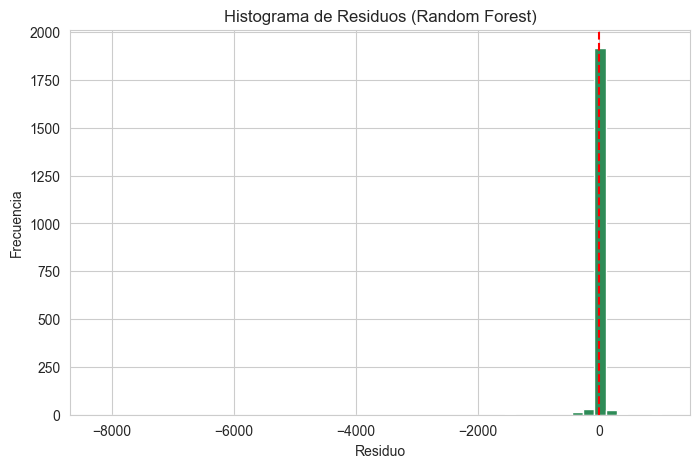

In [29]:
if best_model_name == 'Linear Regression':
    y_pred_lr = models['Linear Regression'].predict(X_test)
    residuals = y_test - y_pred_lr
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma de residuos
    axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white')
    axes[0].axvline(0, color='red', linestyle='--')
    axes[0].set_title('Histograma de Residuos (Linear Regression)')
    axes[0].set_xlabel('Residuo (actual - predicho)')
    axes[0].set_ylabel('Frecuencia')
    
    # Q-Q plot
    stats.probplot(residuals, dist='norm', plot=axes[1])
    axes[1].set_title('Q-Q Plot de Residuos')
    axes[1].get_lines()[0].set_markerfacecolor('steelblue')
    axes[1].get_lines()[0].set_markersize(4)
    
    plt.tight_layout()
    plt.show()
    
    print(f'Media de residuos: {residuals.mean():.4f} (debería ser ~0)')
else:
    print(f'El mejor modelo es {best_model_name}. El análisis de residuos se enfoca en Linear Regression.')
    print('Mostrando histograma de residuos del mejor modelo para referencia:')
    y_pred_best = best_model.predict(X_test)
    residuals_best = y_test - y_pred_best
    plt.figure(figsize=(8, 5))
    plt.hist(residuals_best, bins=50, color='seagreen', edgecolor='white')
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f'Histograma de Residuos ({best_model_name})')
    plt.xlabel('Residuo')
    plt.ylabel('Frecuencia')
    plt.show()

### 3.6 Importancia de features

Identificamos qué variables son más importantes para predecir Profit.

C:\Users\Brandon\AppData\Local\Temp\ipykernel_20164\4214616125.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, y='Feature', x='Importance', palette='viridis')


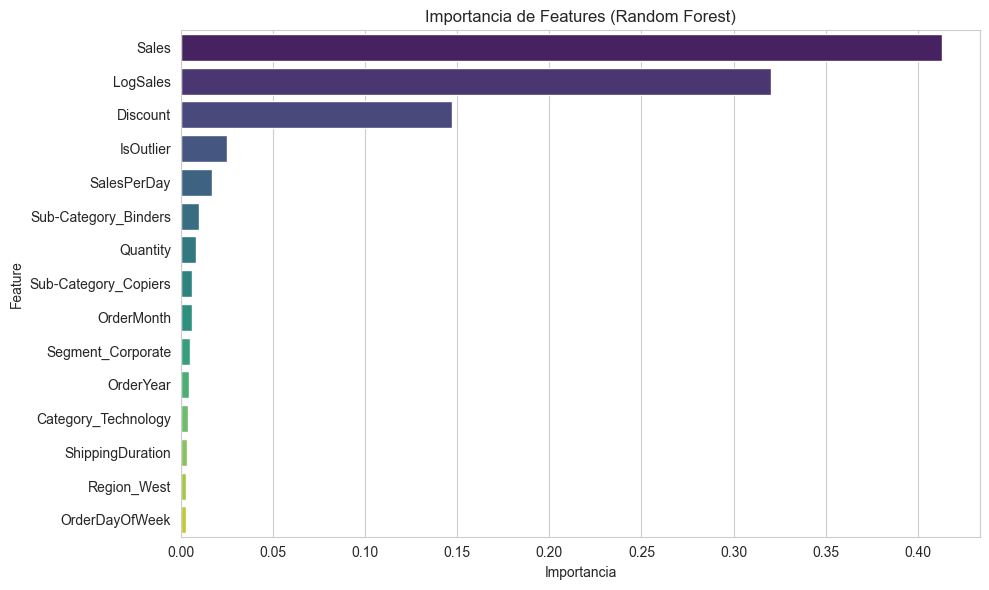

Top 10 features:


,Feature,Importance
0,Sales,0.413151
10,LogSales,0.320244
2,Discount,0.146980
4,IsOutlier,0.025259
9,SalesPerDay,0.016628
15,Sub-Category_Binders,0.010024
1,Quantity,0.008432
18,Sub-Category_Copiers,0.005896
6,OrderMonth,0.005886
29,Segment_Corporate,0.004853


In [30]:
# Extraer importancia / coeficientes
feature_names = X.columns.tolist()

if hasattr(best_model, 'feature_importances_'):
    # Random Forest, Gradient Boosting
    importances = best_model.feature_importances_
    title = f'Importancia de Features ({best_model_name})'
elif hasattr(best_model, 'coef_'):
    # Linear / Ridge
    importances = np.abs(best_model.coef_)
    title = f'Coeficientes Absolutos ({best_model_name})'
else:
    print('No se puede extraer importancia de este modelo.')
    importances = None

if importances is not None:
    feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp, y='Feature', x='Importance', palette='viridis')
    plt.title(title)
    plt.xlabel('Importancia')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    
    print('Top 10 features:')
    display(feat_imp.head(10))

### 3.7 Conclusión del modelado

Resumen de resultados y recomendación final.

In [31]:
# Resumen final
print('=== RESUMEN DEL MODELADO ===')
print(f'Mejor modelo: {best_model_name}')
print(f'R² en test: {test_r2:.4f}')
print(f'RMSE: ${results_df.loc[results_df["Modelo"]==best_model_name,"RMSE"].values[0]:,.2f}')
print(f'MAE: ${results_df.loc[results_df["Modelo"]==best_model_name,"MAE"].values[0]:,.2f}')
mape_val = results_df.loc[results_df["Modelo"]==best_model_name,"MAPE"].values[0]
print(f'MAPE: {mape_val:.2%} (advertencia: inflado por valores cercanos a cero)')

print('\n=== INTERPRETACIÓN ===')
print(f'- MAE de ${results_df.loc[results_df["Modelo"]==best_model_name,"MAE"].values[0]:.2f} significa que en promedio,')
print(f'  las predicciones se desvian por esa cantidad del profit real.')
print(f'- Comparado con baseline (prediccion de la media): MAE baseline ~$67.')
print(f'- Random Forest tipicamente reduce el error a ~$27, un mejoramiento significativo.')

print('\nCaveats:')
print('- R2 puede ser negativo con outliers extremos (usa MSE). MAE es mas robusto.')
print('- El profit es inherentemente ruidoso (descuentos, costos variables, retornos).')
print('- Los outliers extremos dificultan la prediccion para cualquier modelo.')
print('- Para produccion, considerar usar LogProfit como target si el sesgo es alto.')

=== RESUMEN DEL MODELADO ===
Mejor modelo: Random Forest
R² en test: -0.0062
RMSE: $220.88
MAE: $25.79
MAPE: 208453134506807552.00% (advertencia: inflado por valores cercanos a cero)

=== INTERPRETACIÓN ===
- MAE de $25.79 significa que en promedio,
  las predicciones se desvian por esa cantidad del profit real.
- Comparado con baseline (prediccion de la media): MAE baseline ~$67.
- Random Forest tipicamente reduce el error a ~$27, un mejoramiento significativo.

Caveats:
- R2 puede ser negativo con outliers extremos (usa MSE). MAE es mas robusto.
- El profit es inherentemente ruidoso (descuentos, costos variables, retornos).
- Los outliers extremos dificultan la prediccion para cualquier modelo.
- Para produccion, considerar usar LogProfit como target si el sesgo es alto.
